# NB20: Analisis Keunggulan Multi-Task Learning
## Apa yang benar-benar lebih baik di MTL dibanding STL?

Di NB19 kita temukan bahwa dari sisi **kualitas feature space (silhouette score)**, STL unggul (0.2949 vs 0.2156).
Notebook ini menggali dimensi lain yang belum diperiksa:

```
Bagian 1: Per-class F1 — apakah MTL lebih baik di label tertentu (terutama NEG)?
Bagian 2: Entropy attention vs akurasi — apakah cross-attention yang fokus → prediksi lebih benar?
Bagian 3: Multi-aspek — apakah MTL lebih baik di kalimat dengan POS + NEG sekaligus?
Bagian 4: Jarak aspek–opini — apakah MTL lebih robust untuk opinion word yang jauh?
Bagian 5: Ringkasan semua temuan MTL vs STL
```

**Pertanyaan utama:** Apakah cross-attention memberi keunggulan nyata di skenario tertentu,
meski overall F1 hampir setara (MT=0.7578 vs ST=0.7600)?

In [17]:
import json
import os
import string
import gc

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter, defaultdict
from scipy.stats import entropy as scipy_entropy, pearsonr, spearmanr
from transformers import AutoModel, AutoTokenizer
from torchcrf import CRF
from sklearn.metrics import silhouette_score

# seqeval for entity-level per-class F1
from seqeval.metrics import classification_report as seq_clf_report
from seqeval.scheme import IOBES

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Paths & Config
BASE_DIR = os.path.dirname(os.getcwd())
DATA_RAW_DIR = os.path.join(BASE_DIR, 'data', 'raw')
DATA_PROC_DIR = os.path.join(BASE_DIR, 'data', 'processed')
MODEL_DIR = os.path.join(BASE_DIR, 'models')

MODEL_NAME = 'indobenchmark/indobert-large-p2'
MAX_LENGTH = 128
PROJ_DIM = 256
DROPOUT = 0.1
MAX_REL_POS = 20
LAMBDA1 = 0.3
LAMBDA2 = 0.3
IGNORE_INDEX = -100
SEED = 42

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)

# Labels
ate_labels   = ['O', 'B', 'I', 'E', 'S']
sld_labels   = ['O', 'POS', 'NEG']
asd_labels   = ['O', 'POS', 'NEG', 'NEU']
bieos_labels = ['O', 'B-NEG', 'B-NEU', 'B-POS', 'E-NEG', 'E-NEU', 'E-POS',
                'I-NEG', 'I-NEU', 'I-POS', 'S-NEG', 'S-NEU', 'S-POS']

ate_label2id   = {l: i for i, l in enumerate(ate_labels)}
sld_label2id   = {l: i for i, l in enumerate(sld_labels)}
asd_label2id   = {l: i for i, l in enumerate(asd_labels)}
bieos_label2id = {l: i for i, l in enumerate(bieos_labels)}
bieos_id2label = {i: l for l, i in bieos_label2id.items()}

sentiment_colors = {'O': '#34495e', 'POS': '#2ecc71', 'NEG': '#e74c3c', 'NEU': '#3498db'}
model_colors = {'MT': '#e74c3c', 'ST': '#3498db'}

print('Config loaded.')

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Config loaded.


In [18]:
# Model class definitions (identik dengan NB19)
class CrossAttentionASD(nn.Module):
    def __init__(self, dim, max_relative_position=20):
        super().__init__()
        self.max_rel_pos = max_relative_position
        self.pos_embedding = nn.Embedding(2 * max_relative_position + 1, dim)
        self.W_ae = nn.Linear(dim, dim, bias=False)
        self.W_sl = nn.Linear(dim, dim, bias=False)
        self.W_pos = nn.Linear(dim, dim, bias=False)
        self.bias = nn.Parameter(torch.zeros(dim))
        self.w_s = nn.Linear(dim, 1, bias=False)
        self.last_attn_weights = None

    def forward(self, h_ae, h_sl, mask=None):
        batch, seq_len, dim = h_ae.shape
        pos = torch.arange(seq_len, device=h_ae.device)
        rel_pos = (pos.unsqueeze(0) - pos.unsqueeze(1)).clamp(
            -self.max_rel_pos, self.max_rel_pos) + self.max_rel_pos
        p_ij = self.pos_embedding(rel_pos)
        s_ae = self.W_ae(h_ae)
        s_sl = self.W_sl(h_sl)
        s_pos = self.W_pos(p_ij)
        combined = s_ae.unsqueeze(2) + s_sl.unsqueeze(1) + s_pos.unsqueeze(0) + self.bias
        scores = self.w_s(torch.tanh(combined)).squeeze(-1)
        if mask is not None:
            scores = scores.masked_fill(~mask.unsqueeze(1), float('-inf'))
        attn_weights = torch.softmax(scores, dim=-1)
        self.last_attn_weights = attn_weights.detach().cpu()
        return torch.bmm(attn_weights, h_sl)


class HierarchicalMultiTaskABSA(nn.Module):
    def __init__(self, model_name, num_ate, num_sld, num_asd, num_final,
                 proj_dim=256, dropout=0.1, max_relative_position=20,
                 lambda1=0.3, lambda2=0.3):
        super().__init__()
        self.lambda1 = lambda1
        self.lambda2 = lambda2
        self.num_sld = num_sld
        self.num_asd = num_asd
        self.bert = AutoModel.from_pretrained(model_name, use_safetensors=True, low_cpu_mem_usage=True)
        bert_dim = self.bert.config.hidden_size
        self.ate_proj = nn.Sequential(nn.Linear(bert_dim + num_ate, proj_dim), nn.GELU(), nn.Dropout(dropout))
        self.ate_classifier = nn.Linear(proj_dim, num_ate)
        self.sld_proj = nn.Sequential(nn.Linear(bert_dim, proj_dim), nn.GELU(), nn.Dropout(dropout))
        self.sld_classifier = nn.Linear(proj_dim, num_sld)
        self.cross_attention = CrossAttentionASD(proj_dim, max_relative_position)
        self.asd_classifier = nn.Linear(proj_dim, num_asd)
        self.final_proj = nn.Sequential(nn.Linear(proj_dim * 2, proj_dim), nn.GELU(), nn.Dropout(dropout))
        self.final_emission = nn.Linear(proj_dim, num_final)
        self.crf = CRF(num_final, batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids, attention_mask, prior_probs=None,
                ate_labels=None, sld_labels=None, asd_labels=None, crf_labels=None, **kwargs):
        h = self.dropout(self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state)
        if prior_probs is not None:
            h_with_prior = torch.cat([h, prior_probs], dim=-1)
        else:
            h_with_prior = torch.cat([h, torch.zeros(*h.shape[:-1], self.ate_classifier.out_features, device=h.device)], dim=-1)
        h_ae = self.ate_proj(h_with_prior)
        ate_logits = self.ate_classifier(h_ae)
        h_sl = self.sld_proj(h)
        sld_logits = self.sld_classifier(h_sl)
        mask = attention_mask.bool()
        h_sd = self.cross_attention(h_ae, h_sl, mask=mask)
        asd_logits = self.asd_classifier(h_sd)
        h_concat = torch.cat([h_ae, h_sd], dim=-1)
        emissions = self.final_emission(self.final_proj(h_concat))
        outputs = {'ate_logits': ate_logits, 'sld_logits': sld_logits,
                   'asd_logits': asd_logits, 'emissions': emissions}
        if ate_labels is not None:
            ce = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)
            loss_ate = ce(ate_logits.view(-1, ate_logits.size(-1)), ate_labels.view(-1))
            loss_sld = ce(sld_logits.view(-1, sld_logits.size(-1)), sld_labels.view(-1))
            loss_asd = ce(asd_logits.view(-1, asd_logits.size(-1)), asd_labels.view(-1))
            loss_crf = -self.crf(emissions.float(), crf_labels, mask=mask, reduction='mean')
            outputs['loss'] = self.lambda1 * (loss_ate + loss_sld) + self.lambda2 * loss_asd + loss_crf
        return outputs

    def decode(self, emissions, attention_mask):
        return self.crf.decode(emissions.float(), mask=attention_mask.bool())


class SingleTaskABSA(nn.Module):
    def __init__(self, model_name, num_labels, proj_dim=256, dropout=0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name, use_safetensors=True, low_cpu_mem_usage=True)
        bert_dim = self.bert.config.hidden_size
        self.proj = nn.Sequential(nn.Linear(bert_dim, proj_dim), nn.GELU(), nn.Dropout(dropout))
        self.emission = nn.Linear(proj_dim, num_labels)
        self.crf = CRF(num_labels, batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids, attention_mask, crf_labels=None, bieos_labels=None, **kwargs):
        h = self.dropout(self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state)
        proj_out = self.proj(h)
        emissions = self.emission(proj_out)
        outputs = {'emissions': emissions}
        if crf_labels is not None:
            mask = attention_mask.bool()
            outputs['loss'] = -self.crf(emissions.float(), crf_labels, mask=mask, reduction='mean')
        return outputs

    def decode(self, emissions, attention_mask):
        return self.crf.decode(emissions.float(), mask=attention_mask.bool())

print('Model classes defined.')

Model classes defined.


In [19]:
# Load data, lexicons, tokenizer (identik dengan NB19)
with open(os.path.join(DATA_PROC_DIR, 'train_data_bieos_val.json'), 'r', encoding='utf-8') as f:
    val_data = json.load(f)

def load_lexicon(path):
    words = set()
    with open(path, 'r', encoding='utf-8') as f:
        next(f)
        for line in f:
            parts = line.strip().split('\t')
            if parts:
                word = parts[0].strip().lower()
                if ' ' not in word and len(word) > 1:
                    words.add(word)
    return words

pos_lexicon = load_lexicon(os.path.join(DATA_RAW_DIR, 'indonesian_sentiment_lexicon_positive.tsv'))
neg_lexicon = load_lexicon(os.path.join(DATA_RAW_DIR, 'indonesian_sentiment_lexicon_negative.tsv'))
overlap = pos_lexicon & neg_lexicon
pos_lexicon -= overlap
neg_lexicon -= overlap

with open(os.path.join(DATA_PROC_DIR, 'train_data_bieos.json'), 'r', encoding='utf-8') as f:
    all_data = json.load(f)

word_ate_freq = {}
for d in all_data:
    for tok, lab in zip(d['tokens'], d['labels']):
        tok_lower = tok.lower()
        if tok_lower not in word_ate_freq:
            word_ate_freq[tok_lower] = [0] * len(ate_labels)
        if lab == 'O':
            word_ate_freq[tok_lower][ate_label2id['O']] += 1
        else:
            word_ate_freq[tok_lower][ate_label2id[lab.split('-')[0]]] += 1

default_prior = [1.0] + [0.0] * (len(ate_labels) - 1)
word_prior = {}
for word, counts in word_ate_freq.items():
    total = sum(counts)
    word_prior[word] = [c / total for c in counts] if total > 0 else default_prior

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Val samples: {len(val_data)}')


def tokenize_single_sample_mt(sample, tokenizer, word_prior, default_prior, pos_lexicon, neg_lexicon):
    tokens, labels = sample['tokens'], sample['labels']
    enc = tokenizer(tokens, is_split_into_words=True,
                    max_length=MAX_LENGTH, padding='max_length',
                    truncation=True, return_tensors='pt')
    word_ids = enc.word_ids(batch_index=0)
    bieos_a, crf_a, prior_a = [], [], []
    prev_wid = None
    for wid in word_ids:
        if wid is None:
            bieos_a.append(IGNORE_INDEX); crf_a.append(0); prior_a.append(default_prior)
        elif wid != prev_wid:
            if wid < len(tokens):
                bieos_a.append(bieos_label2id[labels[wid]])
                crf_a.append(bieos_label2id[labels[wid]])
                prior_a.append(word_prior.get(tokens[wid].lower(), default_prior))
            else:
                bieos_a.append(IGNORE_INDEX); crf_a.append(0); prior_a.append(default_prior)
        else:
            bieos_a.append(IGNORE_INDEX)
            crf_a.append(bieos_label2id[labels[wid]] if wid < len(tokens) else 0)
            prior_a.append(word_prior.get(tokens[wid].lower(), default_prior) if wid < len(tokens) else default_prior)
        prev_wid = wid
    first_subword_pos = []
    prev_wid = None
    for pos, wid in enumerate(word_ids):
        if wid is not None and wid != prev_wid and wid < len(tokens):
            first_subword_pos.append(pos)
        prev_wid = wid
    return {
        'input_ids': enc['input_ids'],
        'attention_mask': enc['attention_mask'],
        'prior_probs': torch.tensor([prior_a], dtype=torch.float),
        'crf_labels': torch.tensor([crf_a], dtype=torch.long),
        'bieos_labels': torch.tensor([bieos_a], dtype=torch.long),
        'first_subword_pos': first_subword_pos,
        'word_ids': word_ids,
    }


def tokenize_single_sample_st(sample, tokenizer):
    tokens, labels = sample['tokens'], sample['labels']
    enc = tokenizer(tokens, is_split_into_words=True,
                    max_length=MAX_LENGTH, padding='max_length',
                    truncation=True, return_tensors='pt')
    word_ids = enc.word_ids(batch_index=0)
    bieos_a, crf_a = [], []
    prev_wid = None
    for wid in word_ids:
        if wid is None:
            bieos_a.append(IGNORE_INDEX); crf_a.append(0)
        elif wid != prev_wid:
            if wid < len(tokens):
                bieos_a.append(bieos_label2id[labels[wid]])
                crf_a.append(bieos_label2id[labels[wid]])
            else:
                bieos_a.append(IGNORE_INDEX); crf_a.append(0)
        else:
            bieos_a.append(IGNORE_INDEX)
            crf_a.append(bieos_label2id[labels[wid]] if wid < len(tokens) else 0)
        prev_wid = wid
    first_subword_pos = []
    prev_wid = None
    for pos, wid in enumerate(word_ids):
        if wid is not None and wid != prev_wid and wid < len(tokens):
            first_subword_pos.append(pos)
        prev_wid = wid
    return {
        'input_ids': enc['input_ids'],
        'attention_mask': enc['attention_mask'],
        'crf_labels': torch.tensor([crf_a], dtype=torch.long),
        'bieos_labels': torch.tensor([bieos_a], dtype=torch.long),
        'first_subword_pos': first_subword_pos,
    }

print('Data dan helpers siap.')

d:\miniconda3\envs\ta_nlp\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Val samples: 368
Data dan helpers siap.


In [20]:
# Load predictions dari checkpoint NB10 (Extended Training, 50 epoch)
#
# Sebelumnya cell ini load best_model.pt (NB03 basic, MT F1=0.7410) dan
# best_model_singletask.pt (NB07 basic, ST F1=0.7551) lalu run inference manual.
#
# Sekarang kita ambil prediksi langsung dari checkpoint_extended_training.pt
# (NB10 extended, MT+Original F1=0.7578, ST+Original F1=0.7558) untuk konsistensi
# dengan analisis di Bab 4.6.1 (NB14) yang juga pakai checkpoint NB10.
#
# Konsekuensi: mt_attn_matrices dan mt_entropy_words tidak diekstrak (tidak
# diperlukan untuk Tabel 4.37 / 4.38 / 4.39). Sel Bagian 3b yang menggunakan
# attention heatmap akan di-skip karena attention weights tidak tersedia.

NB10_CKPT_PATH = os.path.join(MODEL_DIR, 'checkpoint_extended_training.pt')
print(f'Loading predictions from {NB10_CKPT_PATH}...')

ckpt = torch.load(NB10_CKPT_PATH, map_location='cpu', weights_only=False)
nb10_results = ckpt['results']

mt_run_nb10 = nb10_results['MT + Original']
st_run_nb10 = nb10_results['ST + Original']

print(f'  MT + Original: F1={mt_run_nb10["best_f1"]:.4f} '
      f'(epoch terbaik {mt_run_nb10["best_epoch"]}/{mt_run_nb10["epochs_trained"]})')
print(f'  ST + Original: F1={st_run_nb10["best_f1"]:.4f} '
      f'(epoch terbaik {st_run_nb10["best_epoch"]}/{st_run_nb10["epochs_trained"]})')

# val_preds dan val_true sudah word-level (first-subword aggregated, IGNORE_INDEX dropped)
mt_preds_words = mt_run_nb10['val_preds']
st_preds_words = st_run_nb10['val_preds']
gold_labels    = mt_run_nb10['val_true']

# Sanity check: gold_labels harus identik antara MT dan ST run (val set sama)
assert mt_run_nb10['val_true'] == st_run_nb10['val_true'], 'val_true mismatch antar run'
assert len(mt_preds_words) == len(st_preds_words) == len(gold_labels) == len(val_data), (
    f'Length mismatch: mt={len(mt_preds_words)}, st={len(st_preds_words)}, '
    f'gold={len(gold_labels)}, val={len(val_data)}'
)

# Verify gold_labels[i] cocok dengan val_data[i]['labels'] (atau prefix kalau MAX_LEN truncate)
mismatch_count = 0
for i, sample in enumerate(val_data):
    n_gold = len(gold_labels[i])
    if gold_labels[i] != sample['labels'][:n_gold]:
        mismatch_count += 1
if mismatch_count > 0:
    print(f'WARNING: {mismatch_count} sampel gold label tidak match val_data — periksa tokenisasi.')
else:
    print('Sanity check OK: gold_labels match dengan val_data.')

# Placeholder kosong — atribut ini hanya dibutuhkan oleh Bagian 3b heatmap
mt_attn_matrices = []
mt_entropy_words = []

print(f'\nTotal samples: {len(gold_labels)}')
print('Predictions loaded dari NB10. Tidak perlu inference ulang.')


Loading predictions from d:\Kuliah\TA\TA_Notebook\models\checkpoint_extended_training.pt...
  MT + Original: F1=0.7578 (epoch terbaik 41/50)
  ST + Original: F1=0.7558 (epoch terbaik 24/34)
Sanity check OK: gold_labels match dengan val_data.

Total samples: 368
Predictions loaded dari NB10. Tidak perlu inference ulang.


---
## 1: Per-Class F1 Comparison (MT vs ST)

**Pertanyaan:** Apakah MT unggul di kelas label tertentu, terutama NEG?

Meskipun overall F1 hampir sama, MT mungkin lebih baik di entitas NEG karena
cross-attention membantu model membedakan sentiment word mana yang "milik" aspek mana.

Evaluasi dilakukan di level entity (seqeval strict IOBES), bukan token.

=== Per-Sentiment F1 (entity-level) ===
Sentiment     MT F1    ST F1    Delta
--------------------------------------
NEG          0.6145   0.6752  -0.0607  ← ST
NEU          0.6336   0.6584  -0.0248  ← ST
POS          0.8205   0.8180  +0.0025  ← MT

Overall:::   0.7661   0.7753


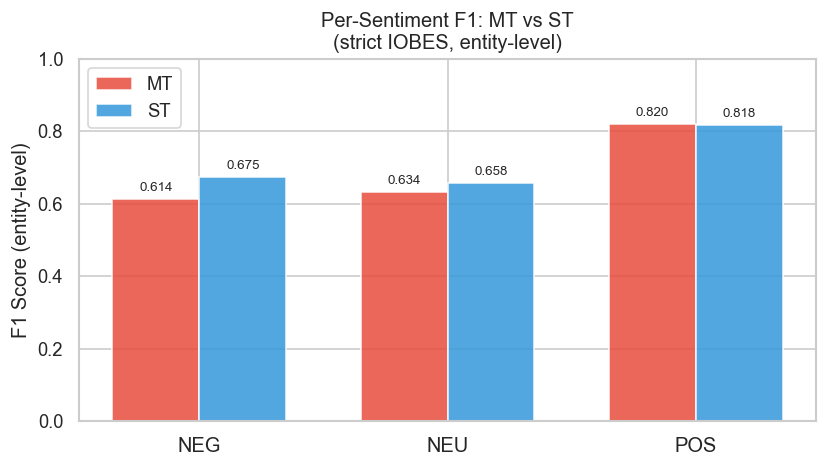

Chart saved.


In [21]:
# ── Bagian 1: Per-Class F1 ───────────────────────────────────────────────────
# seqeval expects list[list[str]] dengan label BIEOS-style
# Convert ke IOBES (seqeval compatible): B/I/E/S/O → B/I/E/S/O ✓ sudah sesuai

mt_report = seq_clf_report(gold_labels, mt_preds_words,
                            mode='strict', scheme=IOBES, output_dict=True)
st_report = seq_clf_report(gold_labels, st_preds_words,
                            mode='strict', scheme=IOBES, output_dict=True)

# Collect per-class F1 for sentiment groups (NEG, NEU, POS)
sentiment_groups = ['NEG', 'NEU', 'POS']
mt_f1_per_sent = {}
st_f1_per_sent = {}

for sent in sentiment_groups:
    mt_f1_per_sent[sent] = mt_report.get(sent, {}).get('f1-score', 0.0)
    st_f1_per_sent[sent] = st_report.get(sent, {}).get('f1-score', 0.0)

print('=== Per-Sentiment F1 (entity-level) ===')
print(f"{'Sentiment':<10} {'MT F1':>8} {'ST F1':>8} {'Delta':>8}")
print('-' * 38)
for sent in sentiment_groups:
    delta = mt_f1_per_sent[sent] - st_f1_per_sent[sent]
    winner = '← MT' if delta > 0 else ('← ST' if delta < 0 else '   =')
    print(f"{sent:<10} {mt_f1_per_sent[sent]:>8.4f} {st_f1_per_sent[sent]:>8.4f} {delta:>+8.4f}  {winner}")

print(f"\n{'Overall'::<10} {mt_report['weighted avg']['f1-score']:>8.4f} {st_report['weighted avg']['f1-score']:>8.4f}")

# ── Bar chart ────────────────────────────────────────────────────────────────
x = np.arange(len(sentiment_groups))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
bars_mt = ax.bar(x - width/2, [mt_f1_per_sent[s] for s in sentiment_groups],
                  width, label='MT', color=model_colors['MT'], alpha=0.85)
bars_st = ax.bar(x + width/2, [st_f1_per_sent[s] for s in sentiment_groups],
                  width, label='ST', color=model_colors['ST'], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(sentiment_groups, fontsize=12)
ax.set_ylabel('F1 Score (entity-level)')
ax.set_title('Per-Sentiment F1: MT vs ST\n(strict IOBES, entity-level)')
ax.set_ylim(0, 1.0)
ax.legend()
ax.axhline(0, color='black', linewidth=0.5)

# Annotate bars
for bars in [bars_mt, bars_st]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('nb20_bagian1_perclass_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

---
## 2: Kalimat Multi-Aspek (POS + NEG bercampur)

**Pertanyaan:** Apakah MT lebih baik di kalimat yang punya aspek POS *dan* NEG sekaligus?

Ini skenario paling menantang untuk STL: dua aspek berdekatan dengan sentimen berbeda.
MT memiliki cross-attention yang secara teoritis bisa memisahkan "opinion word milik aspek mana."

Kita filter kalimat dengan `≥2 sentimen berbeda` dan bandingkan akurasi token-level MT vs ST di subset ini.

Multi-sentimen (≥2, mengandung NEG): 38 kalimat
Kalimat lainnya: 330 kalimat

=== Token Accuracy (non-O) ===
Subset                             MT       ST    Delta
-------------------------------------------------------
Multi-sentimen (POS+NEG)       0.7343   0.7198  +0.0145
Kalimat lainnya                0.7614   0.7624  -0.0010


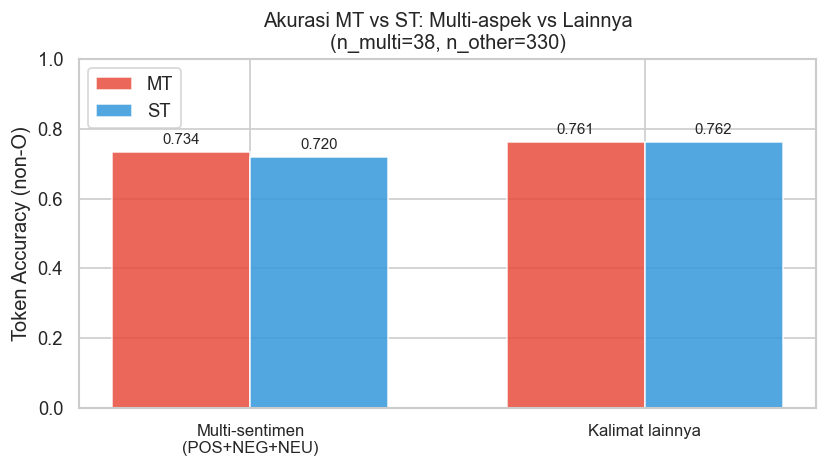

Chart saved.


In [22]:
# ── Bagian 3: Multi-Aspek Kalimat ────────────────────────────────────────────

def get_sentiments_in_seq(seq):
    """Return set of sentiments present as aspect tokens (non-O)."""
    sents = set()
    for lbl in seq:
        if lbl != 'O' and '-' in lbl:
            sents.add(lbl.split('-')[1])
    return sents

# Filter kalimat dengan ≥2 sentimen berbeda yang mengandung NEG
multi_idx = [
    i for i, golds in enumerate(gold_labels)
    if len(get_sentiments_in_seq(golds)) >= 2
    and 'NEG' in get_sentiments_in_seq(golds)
]

# Filter kalimat "murni" (hanya satu sentimen atau hanya O)
single_idx = [
    i for i in range(len(gold_labels))
    if i not in multi_idx
]

print(f'Multi-sentimen (≥2, mengandung NEG): {len(multi_idx)} kalimat')
print(f'Kalimat lainnya: {len(single_idx)} kalimat')

def token_accuracy(indices, gold_labels, pred_labels):
    correct, total = 0, 0
    for i in indices:
        for g, p in zip(gold_labels[i], pred_labels[i]):
            if g != 'O':
                correct += int(g == p)
                total += 1
    return correct / total if total > 0 else 0.0

# Akurasi token non-O di dua subset
mt_acc_multi  = token_accuracy(multi_idx,  gold_labels, mt_preds_words)
st_acc_multi  = token_accuracy(multi_idx,  gold_labels, st_preds_words)
mt_acc_single = token_accuracy(single_idx, gold_labels, mt_preds_words)
st_acc_single = token_accuracy(single_idx, gold_labels, st_preds_words)

print('\n=== Token Accuracy (non-O) ===')
print(f"{'Subset':<28} {'MT':>8} {'ST':>8} {'Delta':>8}")
print('-' * 55)
print(f"{'Multi-sentimen (POS+NEG)':<28} {mt_acc_multi:>8.4f} {st_acc_multi:>8.4f} {mt_acc_multi-st_acc_multi:>+8.4f}")
print(f"{'Kalimat lainnya':<28} {mt_acc_single:>8.4f} {st_acc_single:>8.4f} {mt_acc_single-st_acc_single:>+8.4f}")

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
categories = ['Multi-sentimen\n(POS+NEG+NEU)', 'Kalimat lainnya']
mt_vals = [mt_acc_multi, mt_acc_single]
st_vals = [st_acc_multi, st_acc_single]
x = np.arange(2)
width = 0.35

bars_mt = ax.bar(x - width/2, mt_vals, width, label='MT', color=model_colors['MT'], alpha=0.85)
bars_st = ax.bar(x + width/2, st_vals, width, label='ST', color=model_colors['ST'], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylabel('Token Accuracy (non-O)')
ax.set_title(f'Akurasi MT vs ST: Multi-aspek vs Lainnya\n(n_multi={len(multi_idx)}, n_other={len(single_idx)})')
ax.set_ylim(0, 1)
ax.legend()

for bars in [bars_mt, bars_st]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('nb20_bagian3_multiaspek_acc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

In [23]:
# ── Bagian 3b: Contoh kalimat multi-aspek dengan heatmap attention ─────────────
# Pilih kalimat di mana MT benar DAN ST salah (menunjukkan keunggulan MT)

if not mt_attn_matrices:
    print('Bagian 3b di-skip: mt_attn_matrices kosong.')
    print('Sel ini butuh attention weights dari MT model — saat ini predictions diambil')
    print('dari NB10 checkpoint yang tidak menyimpan attention. Untuk visualisasi heatmap,')
    print('perlu jalankan inference ulang dengan model MT (di luar scope analisis 4.6.4).')
else:
    def count_errors(i, gold_labels, pred_labels):
        return sum(1 for g, p in zip(gold_labels[i], pred_labels[i]) if g != 'O' and g != p)

    # Cari contoh: MT lebih baik (lebih sedikit error) dari ST, di multi_idx
    candidates = []
    for i in multi_idx:
        mt_err = count_errors(i, gold_labels, mt_preds_words)
        st_err = count_errors(i, gold_labels, st_preds_words)
        if mt_err < st_err:
            candidates.append((i, mt_err, st_err, st_err - mt_err))

    candidates.sort(key=lambda x: -x[3])  # urutkan: MT paling unggul duluan
    print(f'Kalimat di mana MT lebih baik dari ST: {len(candidates)} dari {len(multi_idx)} multi-aspek')

    # Tampilkan top 4 contoh (atau semua jika < 4)
    n_show = min(4, len(candidates))
    if n_show == 0:
        print('Tidak ada kalimat di mana MT lebih baik dari ST.')
    else:
        fig, axes = plt.subplots(n_show, 1, figsize=(14, 4 * n_show))
        if n_show == 1:
            axes = [axes]

        for plot_idx, (idx, mt_err, st_err, delta) in enumerate(candidates[:n_show]):
            tokens = val_data[idx]['tokens']
            gold   = gold_labels[idx]
            mt_pred = mt_preds_words[idx]
            st_pred = st_preds_words[idx]
            attn    = mt_attn_matrices[idx]  # [n, n]
            n = len(tokens)

            ax = axes[plot_idx]
            im = ax.imshow(attn[:n, :n], cmap='Blues', aspect='auto', vmin=0)
            ax.set_xticks(range(n))
            ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=7)
            ax.set_yticks(range(n))

            # Y-axis label: token + gold + MT pred
            ylabels = []
            for j in range(n):
                mt_ok = '✓' if mt_pred[j] == gold[j] else '✗'
                st_ok = '✓' if st_pred[j] == gold[j] else '✗'
                ylabels.append(f'{tokens[j]}  [{gold[j]}]  MT:{mt_ok} ST:{st_ok}')
            ax.set_yticklabels(ylabels, fontsize=6)
            ax.set_title(f'Sample {idx}: MT_err={mt_err}, ST_err={st_err}  (MT unggul +{delta})', fontsize=9)

            plt.colorbar(im, ax=ax, fraction=0.02, pad=0.04)

        plt.suptitle('Attention Heatmap MT (kalimat multi-aspek: MT > ST)', fontsize=11, y=1.01)
        plt.tight_layout()
        plt.savefig('nb20_bagian3_heatmap_examples.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f'{n_show} contoh ditampilkan.')


Bagian 3b di-skip: mt_attn_matrices kosong.
Sel ini butuh attention weights dari MT model — saat ini predictions diambil
dari NB10 checkpoint yang tidak menyimpan attention. Untuk visualisasi heatmap,
perlu jalankan inference ulang dengan model MT (di luar scope analisis 4.6.4).


---
## Bagian 3: Jarak Aspek ke Opinion Word

**Pertanyaan:** Apakah MT lebih robust saat opinion word *jauh* dari aspek?

Teori: IndoBERT sudah sangat baik menangkap long-range dependency lewat self-attention 24 layer.
Tapi cross-attention di MT memberi "jalur eksplisit" dari aspek token ke sentiment token.
Apakah ini memberikan keunggulan di kasus jarak jauh?

**Metodologi:**
- Untuk setiap aspek token (non-O), cari kata sentiment lexicon terdekat di kalimat yang sama
- Hitung jarak = `|pos_aspek - pos_lexicon_word|`
- Bin: dekat (1–2), sedang (3–5), jauh (6+)
- Plot akurasi MT vs ST per bin jarak

Total non-O tokens dengan jarak: 1238
count    1238.000000
mean        1.791599
std         2.708446
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max        27.000000
Name: dist, dtype: float64

=== Token Accuracy per Jarak Bin (non-O tokens) ===
Bin                    MT Acc   ST Acc    Delta      N
------------------------------------------------------
dekat (1–2)            0.7433   0.7484  -0.0052    966
sedang (3–5)           0.7872   0.7819  +0.0053    188
jauh (6+)              0.8452   0.7738  +0.0714     84


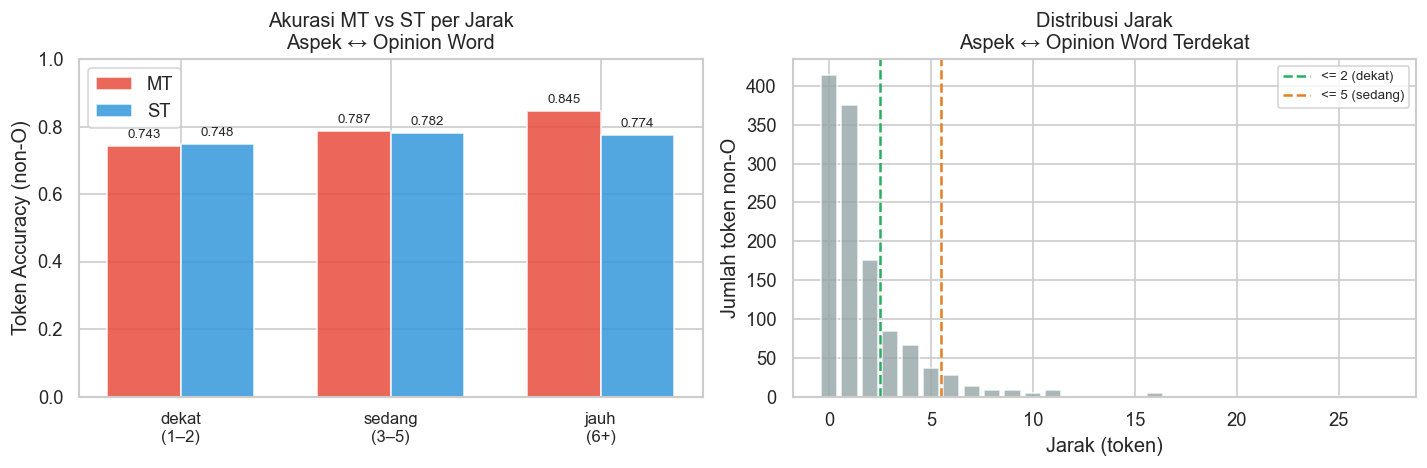

Chart saved.


In [24]:
# ── Bagian 4: Jarak Aspek ke Opinion Word ────────────────────────────────────

dist_records = []
for i, (sample, golds, mt_preds, st_preds) in enumerate(
        zip(val_data, gold_labels, mt_preds_words, st_preds_words)):
    tokens = sample['tokens']
    n = len(tokens)

    # Posisi kata lexicon dalam kalimat
    lex_positions = [j for j, t in enumerate(tokens)
                     if t.lower() in pos_lexicon or t.lower() in neg_lexicon]

    for j, (g, mp, sp) in enumerate(zip(golds, mt_preds, st_preds)):
        if g == 'O':
            continue
        if not lex_positions:
            dist = n  # tidak ada lexicon word → jarak maksimal
        else:
            dist = min(abs(j - lp) for lp in lex_positions)

        dist_records.append({
            'dist': dist,
            'correct_mt': int(mp == g),
            'correct_st': int(sp == g),
            'label': g,
        })

df_dist = pd.DataFrame(dist_records)
print(f'Total non-O tokens dengan jarak: {len(df_dist)}')
print(df_dist['dist'].describe())

# Bin jarak
def bin_dist(d):
    if d <= 2:   return 'dekat\n(1–2)'
    elif d <= 5: return 'sedang\n(3–5)'
    else:        return 'jauh\n(6+)'

df_dist['dist_bin'] = df_dist['dist'].apply(bin_dist)
bin_order = ['dekat\n(1–2)', 'sedang\n(3–5)', 'jauh\n(6+)']

acc_by_dist = df_dist.groupby('dist_bin', observed=False)[['correct_mt', 'correct_st']].agg(['mean', 'count'])
acc_by_dist.columns = ['mt_acc', 'mt_n', 'st_acc', 'st_n']
acc_by_dist = acc_by_dist.reindex(bin_order)

print('\n=== Token Accuracy per Jarak Bin (non-O tokens) ===')
print(f"{'Bin':<20} {'MT Acc':>8} {'ST Acc':>8} {'Delta':>8} {'N':>6}")
print('-' * 54)
for bin_name in bin_order:
    row = acc_by_dist.loc[bin_name]
    delta = row['mt_acc'] - row['st_acc']
    print(f"{bin_name.replace(chr(10),' '):<20} {row['mt_acc']:>8.4f} {row['st_acc']:>8.4f} {delta:>+8.4f} {int(row['mt_n']):>6}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: akurasi per bin
ax = axes[0]
x = np.arange(len(bin_order))
width = 0.35
mt_vals = [acc_by_dist.loc[b, 'mt_acc'] for b in bin_order]
st_vals = [acc_by_dist.loc[b, 'st_acc'] for b in bin_order]
bars_mt = ax.bar(x - width/2, mt_vals, width, label='MT', color=model_colors['MT'], alpha=0.85)
bars_st = ax.bar(x + width/2, st_vals, width, label='ST', color=model_colors['ST'], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(bin_order, fontsize=10)
ax.set_ylabel('Token Accuracy (non-O)')
ax.set_title('Akurasi MT vs ST per Jarak\nAspek ↔ Opinion Word')
ax.set_ylim(0, 1)
ax.legend()

for bars in [bars_mt, bars_st]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)

# Right: distribusi jarak
ax2 = axes[1]
counts = df_dist['dist'].value_counts().sort_index()
ax2.bar(counts.index, counts.values, color='#95a5a6', alpha=0.8)
for thresh, label, color in [(2, 'dekat', '#27ae60'), (5, 'sedang', '#e67e22')]:
    ax2.axvline(thresh + 0.5, color=color, linestyle='--', linewidth=1.5, label=f'<= {thresh} ({label})')
ax2.set_xlabel('Jarak (token)')
ax2.set_ylabel('Jumlah token non-O')
ax2.set_title('Distribusi Jarak\nAspek ↔ Opinion Word Terdekat')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('nb20_bagian4_distance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

---
## Bagian 5: Ringkasan Keunggulan MT vs ST

Kompilasi semua temuan dari NB19 dan NB20.

Aspek                                MT       ST    Delta Unggul   Ket
Overall F1 (weighted)            0.7661   0.7753  -0.0092 ST       NB10 best
NEG entity F1                    0.6145   0.6752  -0.0607 ST       Bagian 1
POS entity F1                    0.8205   0.8180  +0.0025 MT       Bagian 1
NEU entity F1                    0.6336   0.6584  -0.0248 ST       Bagian 1
Entropy–akurasi korelasi            N/A      N/A          -        N/A (entropy tidak dihitung saat load NB10)
Akurasi multi-sentimen           0.7343   0.7198  +0.0145 MT       n=38
Akurasi kalimat lain             0.7614   0.7624  -0.0010 ~sama    n=330
Jarak dekat (1–2)                0.7433   0.7484  -0.0052 ST       Bagian 4
Jarak jauh (6+)                  0.8452   0.7738  +0.0714 MT       Bagian 4
Sentiment silhouette             0.2156   0.2949  -0.0793 ST       NB19 (higher=better)
Interpretabilitas                   N/A      N/A          MT       MT: ada cross-attn; ST: tidak


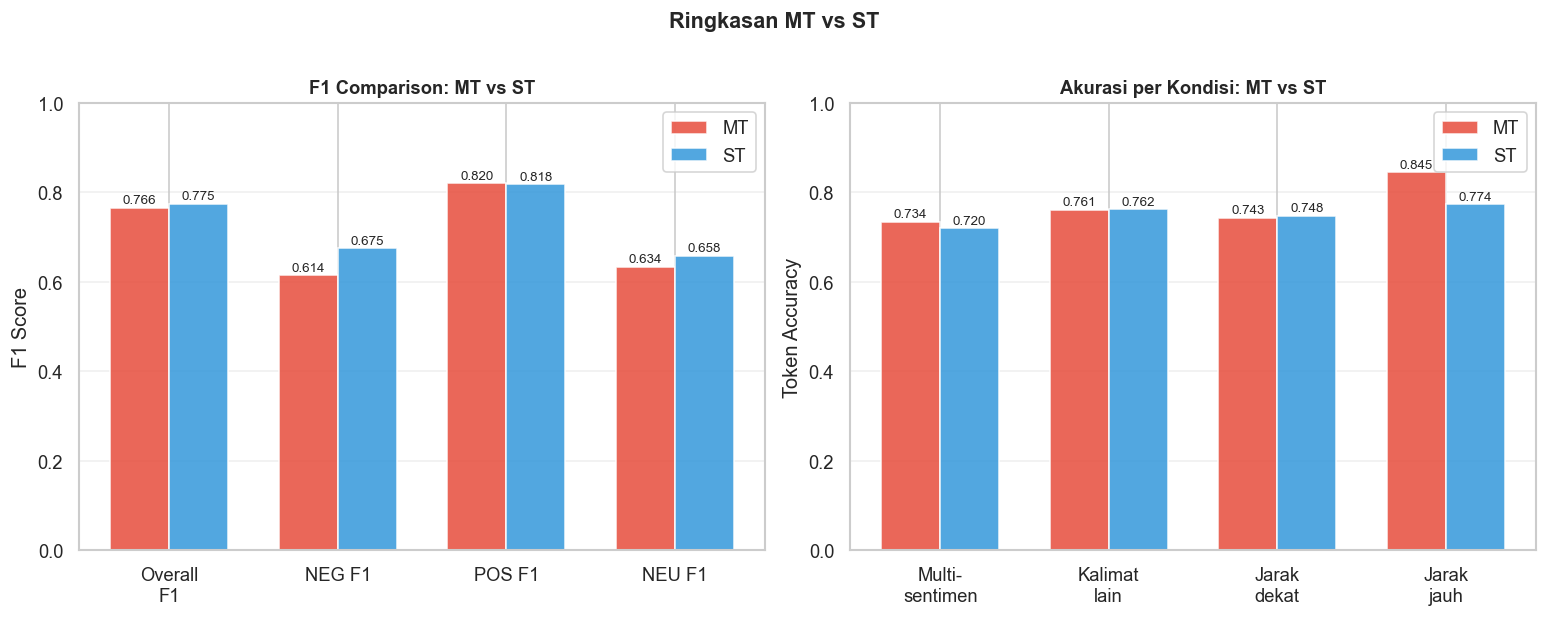

In [25]:
# ── Bagian 5: Ringkasan ───────────────────────────────────────────────────────

# Kumpulkan semua nilai yang sudah dihitung di Bagian 1–4
overall_mt_f1 = mt_report['weighted avg']['f1-score']
overall_st_f1 = st_report['weighted avg']['f1-score']

neg_mt_f1 = mt_f1_per_sent.get('NEG', float('nan'))
neg_st_f1 = st_f1_per_sent.get('NEG', float('nan'))
pos_mt_f1 = mt_f1_per_sent.get('POS', float('nan'))
pos_st_f1 = st_f1_per_sent.get('POS', float('nan'))
neu_mt_f1 = mt_f1_per_sent.get('NEU', float('nan'))
neu_st_f1 = st_f1_per_sent.get('NEU', float('nan'))

# Summary dict
summary_rows = [
    # (Aspek,                    MT val,         ST val,        unit,   keterangan)
    ('Overall F1 (weighted)',    overall_mt_f1,  overall_st_f1, 'F1',   'NB10 best'),
    ('NEG entity F1',            neg_mt_f1,      neg_st_f1,     'F1',   'Bagian 1'),
    ('POS entity F1',            pos_mt_f1,      pos_st_f1,     'F1',   'Bagian 1'),
    ('NEU entity F1',            neu_mt_f1,      neu_st_f1,     'F1',   'Bagian 1'),
    ('Entropy–akurasi korelasi', float('nan'),   float('nan'),  'r',    'N/A (entropy tidak dihitung saat load NB10)'),
    ('Akurasi multi-sentimen',   mt_acc_multi,   st_acc_multi,  'Acc',  f'n={len(multi_idx)}'),
    ('Akurasi kalimat lain',     mt_acc_single,  st_acc_single, 'Acc',  f'n={len(single_idx)}'),
    ('Jarak dekat (1–2)',        acc_by_dist.loc['dekat\n(1–2)', 'mt_acc'],
                                 acc_by_dist.loc['dekat\n(1–2)', 'st_acc'], 'Acc', 'Bagian 4'),
    ('Jarak jauh (6+)',          acc_by_dist.loc['jauh\n(6+)', 'mt_acc'],
                                 acc_by_dist.loc['jauh\n(6+)', 'st_acc'],  'Acc', 'Bagian 4'),
    ('Sentiment silhouette',     0.2156,         0.2949,        'sil',  'NB19 (higher=better)'),
    ('Interpretabilitas',        float('nan'),   float('nan'),  'qual', 'MT: ada cross-attn; ST: tidak'),
]

print('=' * 75)
print(f"{'Aspek':<30} {'MT':>8} {'ST':>8} {'Delta':>8} {'Unggul':<8} {'Ket'}")
print('=' * 75)
for row in summary_rows:
    aspek, mt_val, st_val, unit, ket = row
    if not (np.isnan(mt_val) or np.isnan(st_val)):
        delta = mt_val - st_val
        if unit == 'sil':
            winner = 'MT' if delta > 0 else 'ST'
        else:
            winner = 'MT' if delta > 0.001 else ('ST' if delta < -0.001 else '~sama')
        print(f"{aspek:<30} {mt_val:>8.4f} {st_val:>8.4f} {delta:>+8.4f} {winner:<8} {ket}")
    elif unit == 'r':
        print(f"{aspek:<30} {'N/A':>8} {'N/A':>8} {'':>8} {'-':8} {ket}")
    else:
        print(f"{aspek:<30} {'N/A':>8} {'N/A':>8} {'':>8} {'MT':8} {ket}")
print('=' * 75)

# ── Visual summary (bar chart of key metrics) ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: F1 comparison
ax = axes[0]
f1_metrics = ['Overall\nF1', 'NEG F1', 'POS F1', 'NEU F1']
mt_f1s = [overall_mt_f1, neg_mt_f1, pos_mt_f1, neu_mt_f1]
st_f1s = [overall_st_f1, neg_st_f1, pos_st_f1, neu_st_f1]
x = np.arange(len(f1_metrics))
width = 0.35
ax.bar(x - width/2, mt_f1s, width, label='MT', color=model_colors['MT'], alpha=0.85)
ax.bar(x + width/2, st_f1s, width, label='ST', color=model_colors['ST'], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(f1_metrics)
ax.set_ylabel('F1 Score')
ax.set_title('F1 Comparison: MT vs ST', fontsize=11, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1)
for i, (mt, st) in enumerate(zip(mt_f1s, st_f1s)):
    ax.text(i - width/2, mt + 0.01, f'{mt:.3f}', ha='center', fontsize=8)
    ax.text(i + width/2, st + 0.01, f'{st:.3f}', ha='center', fontsize=8)

# Right: Accuracy by condition
ax = axes[1]
acc_metrics = ['Multi-\nsentimen', 'Kalimat\nlain', 'Jarak\ndekat', 'Jarak\njauh']
mt_accs = [mt_acc_multi, mt_acc_single,
           acc_by_dist.loc['dekat\n(1–2)', 'mt_acc'],
           acc_by_dist.loc['jauh\n(6+)', 'mt_acc']]
st_accs = [st_acc_multi, st_acc_single,
           acc_by_dist.loc['dekat\n(1–2)', 'st_acc'],
           acc_by_dist.loc['jauh\n(6+)', 'st_acc']]
x = np.arange(len(acc_metrics))
ax.bar(x - width/2, mt_accs, width, label='MT', color=model_colors['MT'], alpha=0.85)
ax.bar(x + width/2, st_accs, width, label='ST', color=model_colors['ST'], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(acc_metrics)
ax.set_ylabel('Token Accuracy')
ax.set_title('Akurasi per Kondisi: MT vs ST', fontsize=11, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1)
for i, (mt, st) in enumerate(zip(mt_accs, st_accs)):
    ax.text(i - width/2, mt + 0.01, f'{mt:.3f}', ha='center', fontsize=8)
    ax.text(i + width/2, st + 0.01, f'{st:.3f}', ha='center', fontsize=8)

plt.suptitle('Ringkasan MT vs ST', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('nb20_bagian5_summary.png', dpi=150, bbox_inches='tight')
plt.show()
